# Capítulo 6 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 6. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

e0, T00, Lv, Rv = 0.6113, 273.15, 2.5e6, 461.0
rho, Cp, g, eps = 1.2, 1004.0, 9.8, 0.622
def es_kPa(T_C):
    with np.errstate(over='ignore'):
        return e0*np.exp((Lv/Rv)*(1/T00 - 1/(np.asarray(T_C) + T00)))

## T1 — Convexidade de $e_s(T)$ e supersaturação de misturas

**Solução.** De Clausius–Clapeyron, $e_s' = \frac{L}{\Re_v T^2}e_s$. Derivando de novo:
$$e_s'' = \frac{L\,e_s}{\Re_v T^2}\left(\frac{L}{\Re_v T^2} - \frac{2}{T}\right) = \frac{L\,e_s}{\Re_v T^3}\left(\frac{L}{\Re_v T} - 2\right).$$
Como $L/(\Re_v T) = 5423/T \approx 19 \gg 2$ na faixa atmosférica, $e_s'' > 0$: **convexa**. Pela desigualdade de Jensen/da corda, para dois pontos *sobre* a curva ($e_i = e_s(T_i)$):
$$e_{mix} = f e_s(T_1) + (1{-}f)e_s(T_2) \;>\; e_s\bigl(fT_1 + (1{-}f)T_2\bigr) = e_s(T_{mix}),$$
com desigualdade estrita para $0<f<1$ e $T_1 \ne T_2$: toda mistura de duas parcelas saturadas distintas é supersaturada. ∎

In [2]:
T_, L_, Rv_, e0_, T0_ = sp.symbols('T L R_v e_0 T_0', positive=True)
es_sym = e0_*sp.exp(L_/Rv_*(1/T0_ - 1/T_))
d2 = sp.simplify(sp.diff(es_sym, T_, 2))
display(sp.Eq(sp.Symbol("e_s''"), sp.factor(d2)))
cond = sp.simplify(d2/es_sym*Rv_*T_**4/L_)   # sinal ∝ (L/RvT − 2)·T ... conferir
print('fator de sinal: L/(Rv·T) − 2 =', float(2.5e6/(461*300) - 2), '> 0  ✓ convexa')

Eq(e_s'', L*e_0*(L - 2*R_v*T)*exp(-L/(R_v*T))*exp(L/(R_v*T_0))/(R_v**2*T**4))

fator de sinal: L/(Rv·T) − 2 = 16.076644974692698 > 0  ✓ convexa


## T2 — Critério de Appleman

**Solução.** A exaustão do jato tem $(T_{ex}, e_{ex})$ com $T_{ex} \sim 600$ K e razão fixa vapor/calor: toda a mistura com o ambiente fica sobre a reta de coeficiente angular $G = \Delta e/\Delta T = e_{ex}/(T_{ex} - T_{amb}) \approx$ const ($\sim$0,03–0,04 kPa/K, fixado pela razão emissão de H₂O / calor do querosene). Há contrail quando essa reta, partindo do ponto ambiente, **cruza** $e_s(T)$. Como a reta tem inclinação pequena e fixa enquanto $e_s(T)$ dispara exponencialmente, o cruzamento só é possível onde $e_s$ é minúsculo e mais raso que a reta — isto é, onde $de_s/dT < G$. Com $de_s/dT = Le_s/\Re_vT^2 = G$ resolve-se $T_c \approx -40$ °C: acima disso a curva é sempre mais íngreme e escapa por cima da reta. Por isso contrails são exclusividade da alta troposfera fria (e persistem se o ambiente já está quase saturado sobre gelo).

## T3 — Tempo de formação do nevoeiro

**Solução.** A camada rasa perde energia à taxa $|F^*_{IR}|$ (W/m²). Sua capacidade térmica por área é $C = \rho C_p \Delta z$. Logo $dT/dt = -|F^*_{IR}|/C$ e o tempo para esfriar de $T_0$ a $T_d$ é
$$t_{fog} = \frac{\rho C_p \Delta z\,(T_0 - T_d)}{|F^*_{IR}|}.$$
Papel do **vento**: turbulência mistura a camada — $\Delta z$ cresce e $t_{fog}$ aumenta (vento forte impede nevoeiro de radiação; calmaria o favorece). Papel da **nebulosidade**: nuvens devolvem $I\!\downarrow$ (Cap. 2), reduzindo $|F^*_{IR}|$ — noite nublada não forma.

## T4 — Aritmética fractal

In [3]:
D = 1.35
razao = (1.0/1000.0)**(1 - D)     # L(1 m)/L(1 km) = (l1/l2)^(1-D)
print(f'L(1 m)/L(1 km) = (1/1000)^(1-1,35) = 1000^0,35 = {razao:.1f}×')
print('O perímetro NÃO converge ao refinar a régua — cresce como lei de potência.')

L(1 m)/L(1 km) = (1/1000)^(1-1,35) = 1000^0,35 = 11.2×
O perímetro NÃO converge ao refinar a régua — cresce como lei de potência.


## T5 — Espaçamentos de organização

In [4]:
zi = 1.2
print(f'ruas de cumulus: 2–3·zi = {2*zi:.1f}–{3*zi:.1f} km')
U, N = 15.0, 0.012
print(f'nuvens de onda: 2πU/N = {2*np.pi*U/N/1e3:.1f} km')
print('Ambos na faixa de 2–10 km vista em imagens de satélite ✓')

ruas de cumulus: 2–3·zi = 2.4–3.6 km
nuvens de onda: 2πU/N = 7.9 km
Ambos na faixa de 2–10 km vista em imagens de satélite ✓


---
## N1 — UR máxima da mistura: inverno × dia ameno

T_amb =    5 °C: UR máx da mistura = 135% → bafo visível
T_amb =   15 °C: UR máx da mistura = 107% → bafo visível


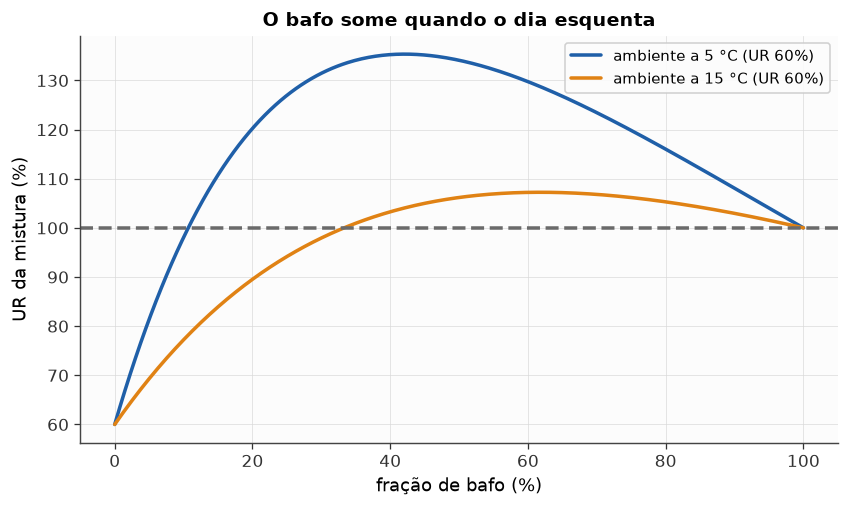

In [5]:
def UR_mistura(T2, UR2, T1=35.0, UR1=100.0):
    e1, e2 = UR1/100*es_kPa(T1), UR2/100*es_kPa(T2)
    f = np.linspace(0, 1, 400)
    T_m, e_m = f*T1 + (1-f)*T2, f*e1 + (1-f)*e2
    UR_m = 100*e_m/es_kPa(T_m)
    return f, UR_m

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for T2, cor in [(5.0, CORES['azul']), (15.0, CORES['laranja'])]:
    f, UR_m = UR_mistura(T2, 60.0)
    ax.plot(100*f, UR_m, color=cor, label=f'ambiente a {T2:.0f} °C (UR 60%)')
    print(f'T_amb = {T2:4.0f} °C: UR máx da mistura = {UR_m.max():.0f}% '
          f'{"→ bafo visível" if UR_m.max() > 100 else "→ bafo invisível"}')
ax.axhline(100, color=CORES['cinza'], ls='--')
ax.set(xlabel='fração de bafo (%)', ylabel='UR da mistura (%)',
       title='O bafo some quando o dia esquenta')
ax.legend()
plt.show()

## N2 — Nebulosidade × nevoeiro

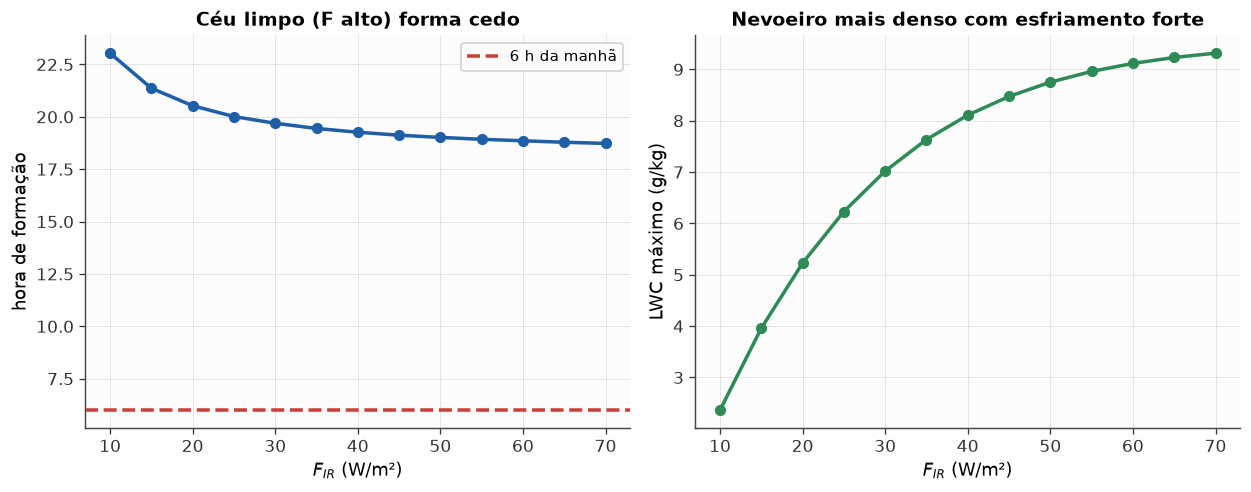

F_IR mínimo que forma nevoeiro antes das 6 h: ~10 W/m²


In [6]:
dz, A = 50.0, 0.2
T_ini, Td, P_kPa = 16.0, 13.0, 100.0
C_cam = rho*Cp*dz
S_sol = lambda th: np.maximum(0.0, 600.0*np.sin(np.pi*((th % 24) - 6)/12))
r_de = lambda T_C: 1e3*eps*es_kPa(T_C)/(P_kPa - es_kPa(T_C))

F_vals = np.arange(10, 71, 5.0)
h_forma, lwc_max = [], []
t = np.linspace(18, 34, 900)
for F_IR in F_vals:
    sol = solve_ivp(lambda th, T: [(-F_IR + (1-A)*S_sol(th))/C_cam*3600.0],
                    [18, 34], [T_ini], t_eval=t, max_step=0.05)
    T_t = sol.y[0]
    LWC = np.maximum(0.0, r_de(Td) - r_de(T_t))
    if (LWC > 0).any():
        h_forma.append(t[LWC > 0][0] % 24)
        lwc_max.append(LWC.max())
    else:
        h_forma.append(np.nan); lwc_max.append(0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.plot(F_vals, h_forma, 'o-', color=CORES['azul'])
ax1.axhline(6, color=CORES['vermelho'], ls='--', label='6 h da manhã')
ax1.set(xlabel='$F_{IR}$ (W/m²)', ylabel='hora de formação',
        title='Céu limpo (F alto) forma cedo')
ax1.legend()
ax2.plot(F_vals, lwc_max, 'o-', color=CORES['verde'])
ax2.set(xlabel='$F_{IR}$ (W/m²)', ylabel='LWC máximo (g/kg)',
        title='Nevoeiro mais denso com esfriamento forte')
fig.tight_layout(); plt.show()

validos = [(F, h) for F, h in zip(F_vals, h_forma) if not np.isnan(h) and (h > 18 or h < 6)]
F_min = min(F for F, h in validos)
print(f'F_IR mínimo que forma nevoeiro antes das 6 h: ~{F_min:.0f} W/m²')

## N3 — $D(\beta)$: calibrando o gerador de nuvens

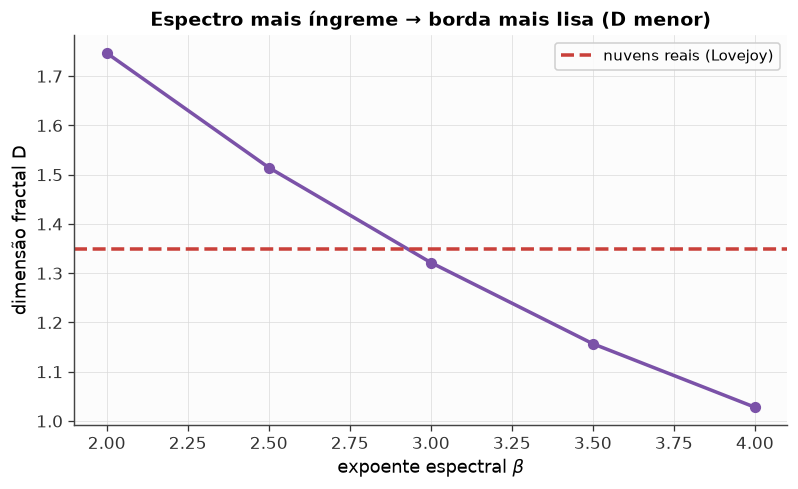

D(β): {2.0: np.float64(1.75), 2.5: np.float64(1.51), 3.0: np.float64(1.32), 3.5: np.float64(1.16), 4.0: np.float64(1.03)}
D = 1,35 em β ≈ 2.9 — próximo do espectro de nuvens observado.


In [7]:
def dimensao_fractal(beta, Ng=512, seed=6):
    rng = np.random.default_rng(seed)
    kx = np.fft.fftfreq(Ng)[:, None]; ky = np.fft.fftfreq(Ng)[None, :]
    k = np.sqrt(kx**2 + ky**2); k[0, 0] = 1.0
    campo = np.fft.ifft2(np.fft.fft2(rng.standard_normal((Ng, Ng)))*k**(-beta/2)).real
    campo = (campo - campo.mean())/campo.std()
    nuvem = campo > 0.5
    viz = (np.roll(nuvem,1,0) & np.roll(nuvem,-1,0) &
           np.roll(nuvem,1,1) & np.roll(nuvem,-1,1))
    borda = nuvem & ~viz
    tams = np.array([2, 4, 8, 16, 32, 64])
    Ns = []
    for s in tams:
        m = borda[:Ng//s*s, :Ng//s*s]
        Ns.append(m.reshape(Ng//s, s, Ng//s, s).any(axis=(1,3)).sum())
    return -np.polyfit(np.log(tams), np.log(Ns), 1)[0]

betas = [2.0, 2.5, 3.0, 3.5, 4.0]
Ds = [np.mean([dimensao_fractal(b, seed=s) for s in (1, 2, 3)]) for b in betas]

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(betas, Ds, 'o-', color=CORES['roxo'])
ax.axhline(1.35, color=CORES['vermelho'], ls='--', label='nuvens reais (Lovejoy)')
ax.set(xlabel='expoente espectral $\\beta$', ylabel='dimensão fractal D',
       title='Espectro mais íngreme → borda mais lisa (D menor)')
ax.legend()
plt.show()
beta_alvo = np.interp(1.35, Ds[::-1], betas[::-1])
print('D(β):', {b: round(d, 2) for b, d in zip(betas, Ds)})
print(f'D = 1,35 em β ≈ {beta_alvo:.1f} — próximo do espectro de nuvens observado.')

## N4 — Espaçamento das ondas × vento

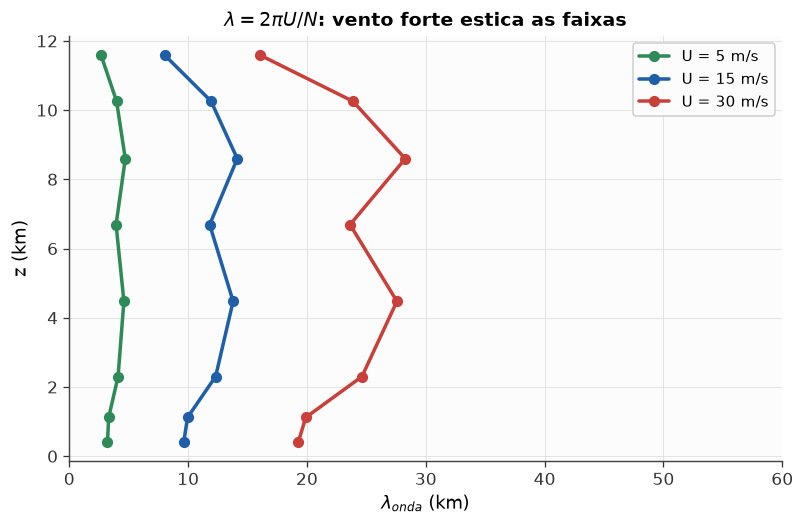

Vento forte → λ maior (padrão mais espaçado). Limites de visibilidade:
λ muito grande não cabe no céu visível; λ pequeno demais borra na turbulência;
e só há NUVEM de onda se a crista atingir o LCL da camada (Cap. 4).


In [8]:
z_km  = np.array([0.08, 0.76, 1.48, 3.12, 5.83, 7.55, 9.64, 10.87, 12.30])
theta = np.array([300.5, 302.5, 304.5, 307.5, 311.5, 315.0, 318.0, 320.5, 327.0])
zm = 0.5*(z_km[1:] + z_km[:-1])
N = np.sqrt(np.maximum(g/(0.5*(theta[1:]+theta[:-1]))*np.diff(theta)/np.diff(z_km*1e3), 0))

fig, ax = plt.subplots(figsize=(8, 4.8))
for U, cor in [(5, CORES['verde']), (15, CORES['azul']), (30, CORES['vermelho'])]:
    lam = 2*np.pi*U/np.maximum(N, 1e-9)/1e3
    ax.plot(lam, zm, 'o-', color=cor, label=f'U = {U} m/s')
ax.set(xlabel='$\\lambda_{onda}$ (km)', ylabel='z (km)', xlim=(0, 60),
       title='$\\lambda = 2\\pi U/N$: vento forte estica as faixas')
ax.legend()
plt.show()
print('Vento forte → λ maior (padrão mais espaçado). Limites de visibilidade:')
print('λ muito grande não cabe no céu visível; λ pequeno demais borra na turbulência;')
print('e só há NUVEM de onda se a crista atingir o LCL da camada (Cap. 4).')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*